# 04: Split Conformal Prediction — Basics

## Goals
1. Generate synthetic regression data (simple model, known noise distribution)
2. Fit a base predictor (linear regression)
3. Split data into train / calibration / test
4. Compute nonconformity scores on the calibration set
5. Build prediction intervals using the empirical quantile Q̂(1 - α)
6. Verify: empirical coverage on the test set should be ≥ 1 - α

## Setup
- Synthetic data: y = f(x) + noise
- α = 0.1 (target 90% coverage)
- No financial data yet — verifying the conformal machinery in isolation

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# Generate synthetic regression data
# y = 2x + 1 + noise
n_total = 1000
X = np.random.uniform(-5, 5, n_total)
noise = np.random.normal(0, 1, n_total)
Y = 2 * X + 1 + noise

In [5]:
# Train / Calibration / Test split
n_train = 500
n_cal = 250
# Remaining 250 for test

X_train, Y_train = X[:n_train], Y[:n_train]
X_cal, Y_cal = X[n_train:n_train + n_cal], Y[n_train:n_train + n_cal]
X_test, Y_test = X[n_train + n_cal:], Y[n_train + n_cal:]

In [6]:
# Fit linear regression: y = ax + b
coeffs = np.polyfit(X_train, Y_train, deg=1)
# Our predict function returns our y_hat
predict = np.poly1d(coeffs)

In [7]:
alpha = 0.1

# Nonconformity scores on calibration set
scores = np.abs(Y_cal - predict(X_cal))

# Q_hat(1 - alpha) - empirical quantile of calibration scores
q_hat = np.quantile(scores, 1 - alpha)

In [13]:
# Prediction intervals on test set
# [predict(X_test) - q_hat, predict(X_hat) + q_hat]
lower = predict(X_test) - q_hat
upper = predict(X_test) + q_hat

In [14]:
# Checking coverage
coverage = np.mean((Y_test >= lower) & (Y_test <= upper))
print(f"Empirical coverage: {coverage:.4f} (target: {1 - alpha:.2f})")

Empirical coverage: 0.9000 (target: 0.90)


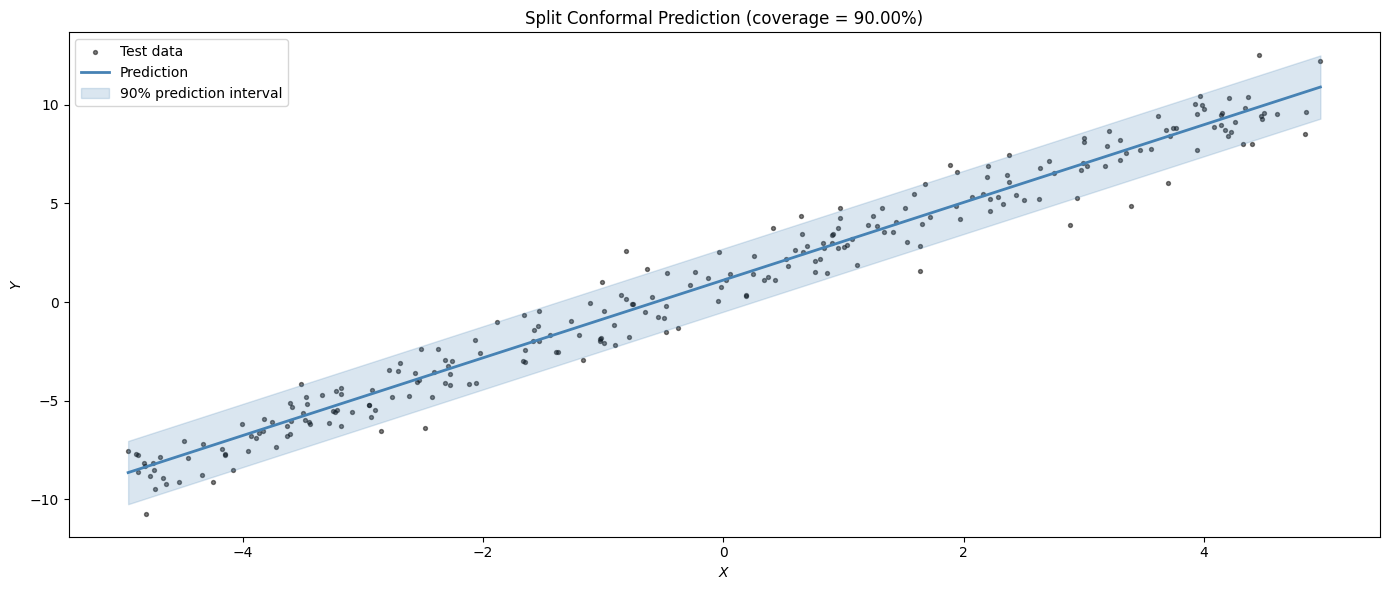

In [15]:
# Sort by X for clean visualization
sort_idx = np.argsort(X_test)
X_sorted = X_test[sort_idx]
Y_sorted = Y_test[sort_idx]
lower_sorted = lower[sort_idx]
upper_sorted = upper[sort_idx]

fig, ax = plt.subplots(figsize=(14, 6))

ax.scatter(X_sorted, Y_sorted, s=8, alpha=0.5, color='black', label='Test data')
ax.plot(X_sorted, predict(X_sorted), color='steelblue', linewidth=2, label='Prediction')
ax.fill_between(X_sorted, lower_sorted, upper_sorted, alpha=0.2, color='steelblue', label=f'90% prediction interval')
ax.set_xlabel('$X$')
ax.set_ylabel('$Y$')
ax.set_title(f'Split Conformal Prediction (coverage = {coverage:.2%})')
ax.legend()

plt.tight_layout()
plt.show()